# Lab Segmentation 1

In [13]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


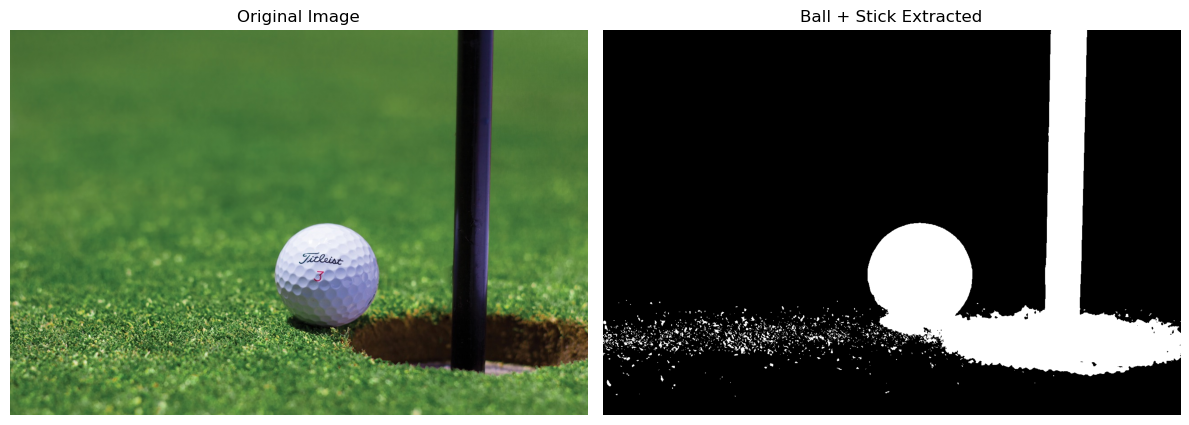

In [14]:
## For all requirements: The quality of the results is evaluated.


# 1- Read the image 
# [VERY IMPORTANT] and convert it to float: image = image.astype(float)

# read image golf



# 2- Retreive the 3 channels of the image(R,G,B) (will be used in the coming steps)


# 3- Visually (not by code) detect the dominating color channel (C) for the backgroung (R, G or B)

# 4- Draw the dominating channel (r, g or b) thresholded by some threshold (to make sure your choice is meaningful)


# 5- Get an intuitive way(There is a very simple way) to make a mask that can get the pixels where the values of the dominating channels 
# have larger values than the other channels with an appropriate threshold

# 6- display the binarized image


# Load image
img = io.imread("./imgs/exp1/golf.jpeg")
img = img.astype(float)

redGolfImage = img[:,:,0]
greenGolfImage = img[:,:,1]
blueGolfImage = img[:,:,2]



def detectGolfBackground(image):
    height, width, _ = image.shape
    outputImage = np.copy(rgb2gray(image))

    for i in range(height):
        for j in range(width):
            if(image[i][j][1] - image[i][j][2] < 40 or image[i][j][1] < 90):
                outputImage[i][j] = 255
            else:
                outputImage[i][j] = 0
    
    return outputImage

foreground = detectGolfBackground(img)

# Show results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img / 255)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Ball + Stick Extracted")
plt.imshow(foreground)
plt.axis("off")

plt.tight_layout()
plt.show()




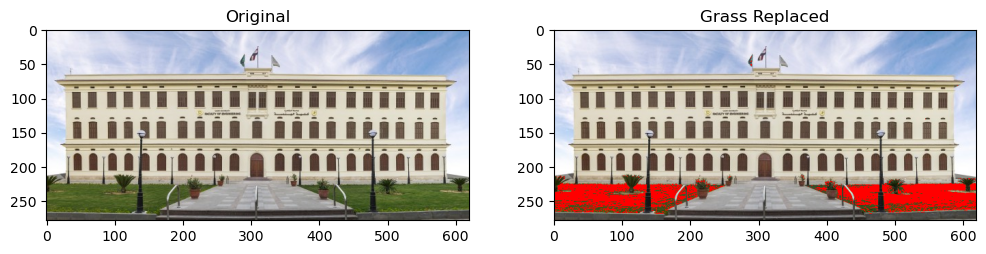

In [15]:
# 1- Get the required RGB color (Using a color picker)


# 2- Read image

# 3- extract R, G and B channels (as float)

# 4- calculate differences FOR EACH CHANNEL (between the image and the required pixel value)

# 5- calculate overall distance from the given RGB color (use any appropriate distance measure, take care of the minus distances)

# 6-  create a mask by thresholding the differences

# 7- In the input image, Replace the pixels of the mask with the following color
# R = 230 , G = 90 , B=40

# 8- show the image or save it

img2 = io.imread('imgs/exp2/cufe.png')
img_float = img2.astype(float)

# Define the color to target (grass green)
target_color = np.array([60, 140, 60], dtype=float)  # change if needed

# Define the color to replace with (red for visibility)
replace_color = np.array([255, 0, 0], dtype=float)

# Compute Euclidean distance between each pixel and target color
distance = np.sqrt(np.sum((img_float - target_color) ** 2, axis=2))

# Threshold to define "close" pixels (tune the threshold)
threshold = 60.0
mask = distance < threshold

# Replace pixels within range
new_img = img_float.copy()
new_img[mask] = replace_color

# Display result
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img2.astype(np.uint8))
plt.subplot(1,2,2)
plt.title('Grass Replaced')
plt.imshow(new_img.astype(np.uint8))
plt.show()